start--->generateoutline--->generateblog--->end

In [13]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
import os
load_dotenv()
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
model=ChatOpenAI()

In [14]:
# define state
class PromptChaining(TypedDict):
    topic:str
    outline:str
    blog:str

In [15]:
# create function/node gen_outline
def gen_outline(state:PromptChaining)->PromptChaining:
    topic=state['topic']
    prompt=PromptTemplate(
        template="""You are a helpful assistant , expert in designing the outline of topic given to you , so that the outline can further be used to create a blog over it. \n topic: {topic}""",
        input_variables=['topic']
    )
    f_prompt=prompt.format(topic=topic)
    outline=model.invoke(f_prompt).content
    state["outline"]=outline
    return state

def gen_blog(state:PromptChaining)->PromptChaining:
    topic=state['topic']
    outline=state["outline"]
    prompt=PromptTemplate(
        template="""You are a helpful assistant , expert in converting the outline into blog,  \n topic: {topic} \n--> outline: {outline} """,
        input_variables=['topic','outline']
    )
    f_prompt=prompt.format(topic=topic,outline=outline)
    blog=model.invoke(f_prompt).content
    state["blog"]=blog
    return state


In [16]:
# create graph
graph=StateGraph(PromptChaining)
# add node
graph.add_node("gen_outline",gen_outline)
graph.add_node("gen_blog",gen_blog)
# add edges
graph.add_edge(START,"gen_outline")
graph.add_edge("gen_outline","gen_blog")
graph.add_edge("gen_blog",END)




In [17]:
# compile graph
workflow=graph.compile()

In [18]:
# invoke graph by passing initial state
initial_state={"topic":"Artificial Intelligence rise in india"}
final_state=workflow.invoke(initial_state)
print(final_state)

{'topic': 'Artificial Intelligence rise in india', 'outline': 'I. Introduction\n    A. Definition of Artificial Intelligence\n    B. Overview of the rise of Artificial Intelligence in India\n\nII. History of Artificial Intelligence in India\n    A. Timeline of major developments in AI in India\n    B. Key players and institutions leading the AI revolution in India\n\nIII. Current Landscape of Artificial Intelligence in India\n    A. Industries and sectors embracing AI technology\n    B. Challenges and opportunities in the AI market in India\n    C. Government initiatives and policies supporting AI development\n\nIV. Impact of Artificial Intelligence on Indian society and economy\n    A. Job disruptions and skills gap created by AI\n    B. Opportunities for growth and innovation in Indian industries\n    C. Ethical implications of AI deployment in India\n\nV. Future outlook of Artificial Intelligence in India\n    A. Predictions for the growth of the AI market in India\n    B. Emerging 

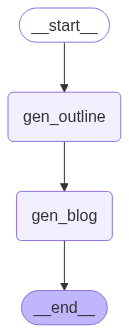

In [19]:
# how to see the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())